# Task 7.2 — Rabi sequence

For each Rabi run we record the lock-in voltage as the MW pulse length $\tau$ is swept.
The signal shows two superimposed trends:

1. **Coherent oscillation** — the spin precesses between $|0\rangle$ and $|{-1}\rangle$ at the Rabi frequency $\Omega_R$ set by the driving MW field.
2. **Envelope decay** — the oscillation amplitude collapses on a timescale $T_R$ from inhomogeneous dephasing, MW field/phase noise, and optical-pumping during readout.

**Fit model** (simplest form capturing both):
$$
V(\tau) \;=\; A\,e^{-\tau / T_R}\,\cos(2\pi f_R \tau + \phi) \;+\; C
$$

with $f_R = \Omega_R / 2\pi$ and the $\pi$-pulse duration $T_\pi = 1/(2 f_R)$.

**Sign convention:** same as ODMR — the lock-in reads $\propto (I_\text{off} - I_\text{res})$, so the constant offset $C$ is near zero.


In [1]:
%matplotlib inline
import json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

RUN_DIRS = sorted(glob.glob(r"ALEXQUADRAT\20260122_*Rabi"))
print(f"{len(RUN_DIRS)} Rabi runs found:")
for d in RUN_DIRS:
    print(" ", os.path.basename(d))


6 Rabi runs found:
  20260122_143242_Rabi
  20260122_143410_Rabi
  20260122_144020_Rabi
  20260122_144344_Rabi
  20260122_144702_Rabi
  20260122_145025_Rabi


In [2]:
def load_run(run_dir):
    with open(os.path.join(run_dir, "MeasurementParameters.json")) as f:
        params = json.load(f)["Parameters"]
    csv_dir = os.path.join(run_dir, "setCounter_['0']")
    csv = glob.glob(os.path.join(glob.escape(csv_dir), "*.csv"))[0]
    df = pd.read_csv(csv, sep=";")
    df.columns = [c.strip() for c in df.columns]
    tau_ns = df["programPulseSequenceAndRun"].to_numpy(dtype=float)
    V      = df["readOutput"].to_numpy(dtype=float)
    return params, tau_ns, V


runs = []
for d in RUN_DIRS:
    p, tau, V = load_run(d)
    runs.append({
        "name":    os.path.basename(d),
        "P_dB":    p["MW_Power_dB"],
        "f_MW":    p["MW_Frequency_Hz"],
        "step_ns": p["Steps_ns"],
        "tau":     tau,
        "V":       V,
    })

# Sort by MW power for nicer plots / table
runs.sort(key=lambda r: r["P_dB"])

pd.DataFrame([{"run": r["name"], "MW [dB]": r["P_dB"],
               "step [ns]": r["step_ns"], "N pts": len(r["tau"])} for r in runs])


,run,MW [dB],step [ns],N pts
0,20260122_144344_Rabi,-13.0,50,199
1,20260122_144020_Rabi,-3.0,50,199
2,20260122_143242_Rabi,0.0,200,50
3,20260122_143410_Rabi,0.0,50,199
4,20260122_144702_Rabi,3.0,50,199
5,20260122_145025_Rabi,7.0,50,199


## Raw overview

All six runs on one axis. The first run (200 ns step) is a coarse scan — kept for the overview, but **excluded from fits** below since it severely undersamples the high-power oscillation.


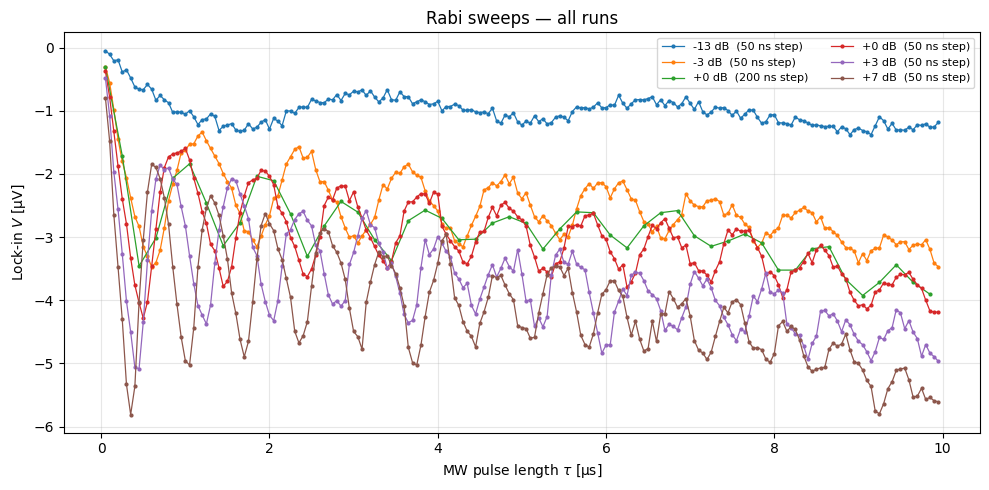

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for r in runs:
    label = f"{r['P_dB']:+.0f} dB  ({r['step_ns']} ns step)"
    ax.plot(r["tau"] / 1e3, r["V"] * 1e6, ".-", ms=4, lw=0.9, label=label)
ax.set_xlabel(r"MW pulse length $\tau$ [µs]")
ax.set_ylabel(r"Lock-in $V$ [µV]")
ax.set_title("Rabi sweeps — all runs")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Fit — damped cosine + linear baseline

Two of the runs (0 dB, +3 dB) show a strong slow drift in the lock-in baseline (~2 µV over 10 µs) comparable to the Rabi amplitude — likely laser power drift or partial $T_1$ recovery during the readout window. Without a baseline term, the optimizer prefers to model that drift as a low-frequency cosine and misses the real oscillation. So the model is:

$$V(\tau) = A\,e^{-\tau/T_R}\cos(2\pi f_R \tau + \phi) + C + D\tau$$

Initial $f_R$: take the strongest FFT bin of the *detrended* signal **above** $f_{min} = 1.5/T_{window}$ (we require at least 1.5 oscillations in the window — anything slower is drift, not Rabi).

In [4]:
def damped_cos(tau, A, T_R, f_R, phi, C, D):
    return A * np.exp(-tau / T_R) * np.cos(2 * np.pi * f_R * tau + phi) + C + D * tau


def fft_freq_guess(tau_ns, V, f_min):
    # detrend (remove linear baseline) before FFT, then pick strongest bin above f_min
    p = np.polyfit(tau_ns, V, 1)
    Vd = V - np.polyval(p, tau_ns)
    dt = np.median(np.diff(tau_ns))
    Y = np.fft.rfft(Vd)
    freqs = np.fft.rfftfreq(len(Vd), d=dt)
    mask = freqs >= f_min
    if not mask.any():
        return f_min
    k_local = np.argmax(np.abs(Y[mask]))
    return freqs[mask][k_local]


def fit_rabi(tau_ns, V):
    T_window = tau_ns.max() - tau_ns.min()
    f_min = 1.5 / T_window                    # demand >=1.5 oscillations in window
    f0 = fft_freq_guess(tau_ns, V, f_min)
    A0 = (V.max() - V.min()) / 2
    C0 = V.mean()
    T0 = T_window / 2
    D0 = (V[-5:].mean() - V[:5].mean()) / T_window

    p0 = [A0, T0, f0, 0.0, C0, D0]
    bounds = (
        [0,         50,          f_min,  -np.pi, -np.inf, -np.inf],
        [10 * A0,   1e6,         5e-2,    np.pi,  np.inf,  np.inf],
    )
    popt, pcov = curve_fit(damped_cos, tau_ns, V, p0=p0, bounds=bounds, maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr


# Fit only the fine-step runs
fit_runs = [r for r in runs if r["step_ns"] <= 100]

results = []
for r in fit_runs:
    popt, perr = fit_rabi(r["tau"], r["V"])
    A, T_R, f_R, phi, C, D = popt
    f_R_MHz   = f_R * 1e3                         # 1/ns -> MHz
    T_pi_ns   = 1 / (2 * f_R)
    T_pi_err  = perr[2] / (2 * f_R**2)
    results.append({
        "run":          r["name"],
        "MW [dB]":      r["P_dB"],
        "f_R [MHz]":    f_R_MHz,
        "Δf_R [MHz]":   perr[2] * 1e3,
        "T_π [ns]":     T_pi_ns,
        "ΔT_π [ns]":    T_pi_err,
        "T_R [ns]":     T_R,
        "A [µV]":       A * 1e6,
        "C [µV]":       C * 1e6,
        "D [µV/µs]":    D * 1e6 * 1e3,           # µV per µs
        "popt":         popt,
    })

table = pd.DataFrame(results).drop(columns="popt")
table

,run,MW [dB],f_R [MHz],Δf_R [MHz],T_π [ns],ΔT_π [ns],T_R [ns],A [µV],C [µV],D [µV/µs]
0,20260122_144344_Rabi,-13.0,0.286751,0.003017,1743.674969,18.344711,3933.894972,0.605102,-0.783084,-0.041393
1,20260122_144020_Rabi,-3.0,0.831089,0.002161,601.620119,1.564456,4373.797279,1.304490,-2.009494,-0.104085
2,20260122_143410_Rabi,0.0,1.047813,0.002186,477.184451,0.995381,4634.729252,1.451605,-2.336372,-0.139442
3,20260122_144702_Rabi,3.0,1.258616,0.002387,397.261660,0.753396,4152.324926,1.731387,-2.819405,-0.182911
4,20260122_145025_Rabi,7.0,1.472371,0.002627,339.588406,0.606003,3982.778554,1.974383,-3.125225,-0.201567


## Per-run fit plots


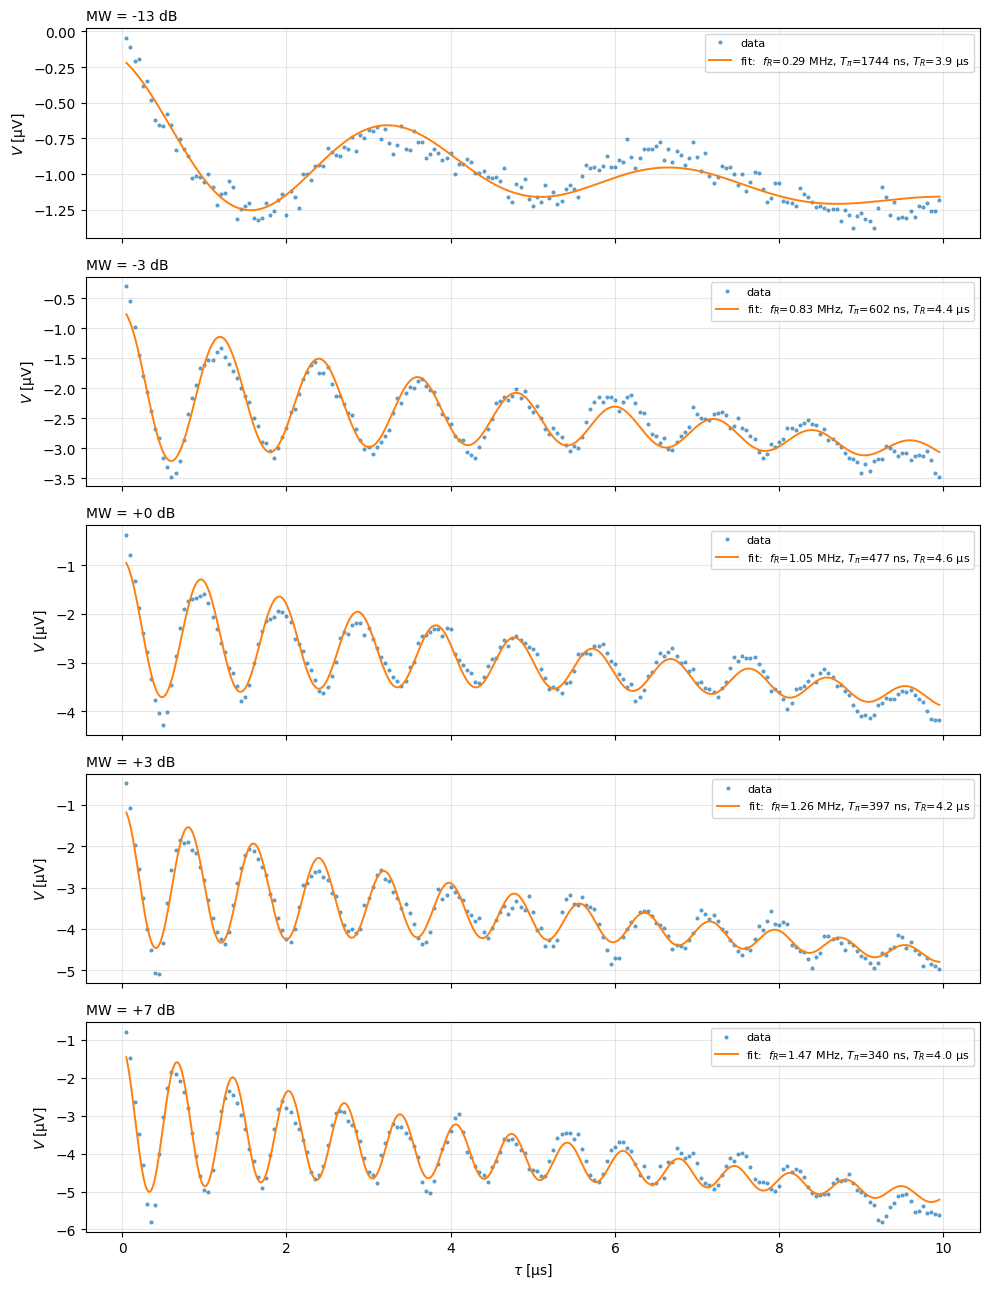

In [5]:
n = len(fit_runs)
fig, axes = plt.subplots(n, 1, figsize=(10, 2.6 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, r, res in zip(axes, fit_runs, results):
    tau = r["tau"]
    ax.plot(tau / 1e3, r["V"] * 1e6, ".", ms=4, alpha=0.6, label="data")
    tau_fine = np.linspace(tau.min(), tau.max(), 2000)
    ax.plot(tau_fine / 1e3, damped_cos(tau_fine, *res["popt"]) * 1e6,
            "-", lw=1.4, label=f"fit:  $f_R$={res['f_R [MHz]']:.2f} MHz, "
                               f"$T_\\pi$={res['T_π [ns]']:.0f} ns, "
                               f"$T_R$={res['T_R [ns]']/1e3:.1f} µs")
    ax.set_ylabel(r"$V$ [µV]")
    ax.set_title(f"MW = {r['P_dB']:+.0f} dB", loc="left", fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel(r"$\tau$ [µs]")
plt.tight_layout(); plt.show()


## Power scaling: $\Omega_R \propto \sqrt{P}$

The MW field amplitude $B_1 \propto \sqrt{P}$, and $\Omega_R = \gamma_e B_1$, so
$f_R$ vs $\sqrt{P_\text{lin}}$ should be a straight line through the origin
($P_\text{lin} = 10^{P[\text{dB}]/10}$, relative units — only the slope matters).

**Sanity check:** if the MW chain (source + amplifier) is linear, the per-point ratio
$f_R / \sqrt{P_\text{lin}}$ should be constant. If it *drops* at high power, the amplifier
is being driven into compression and the MW field at the sample no longer grows as $\sqrt{P}$.

MW [dB]  sqrt(P_lin)  f_R [MHz]   f_R / sqrt(P_lin)  [MHz]
   -13       0.224       0.287          1.281
    -3       0.708       0.831          1.174
    +0       1.000       1.048          1.048
    +3       1.413       1.259          0.891
    +7       2.239       1.472          0.658


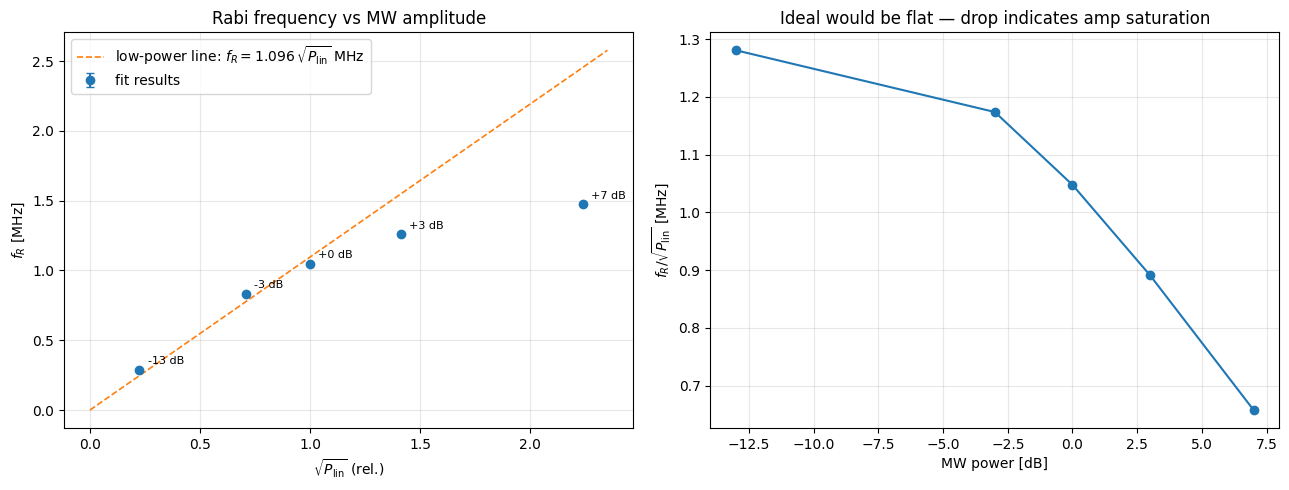


low-power slope (P <= 0 dB):  1.096  MHz / sqrt(P_lin)
high-power deviation: 51% of low-power slope at +7 dB


In [6]:
P_dB     = np.array([r["MW [dB]"]    for r in results])
f_R_MHz  = np.array([r["f_R [MHz]"]  for r in results])
df_R     = np.array([r["Δf_R [MHz]"] for r in results])
sqrtP    = 10 ** (P_dB / 20)

# Per-point slope ratio — flat = ideal sqrt(P), downward = saturation
ratio = f_R_MHz / sqrtP

print("MW [dB]  sqrt(P_lin)  f_R [MHz]   f_R / sqrt(P_lin)  [MHz]")
for d, s, f, r in zip(P_dB, sqrtP, f_R_MHz, ratio):
    print(f" {d:+5.0f}    {s:8.3f}     {f:7.3f}        {r:7.3f}")

# Linear fit through origin using only the low-power runs
LOW_MASK = P_dB <= 0
m_lo  = np.sum(sqrtP[LOW_MASK] * f_R_MHz[LOW_MASK]) / np.sum(sqrtP[LOW_MASK]**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(sqrtP, f_R_MHz, yerr=df_R, fmt="o", capsize=3, label="fit results")
xx = np.linspace(0, sqrtP.max() * 1.05, 100)
ax.plot(xx, m_lo * xx, "--", lw=1.2, color="C1",
        label=fr"low-power line: $f_R = {m_lo:.3f}\,\sqrt{{P_\text{{lin}}}}$ MHz")
for d, s, f in zip(P_dB, sqrtP, f_R_MHz):
    ax.annotate(f"{d:+.0f} dB", (s, f), textcoords="offset points",
                xytext=(6, 4), fontsize=8)
ax.set_xlabel(r"$\sqrt{P_\text{lin}}$ (rel.)")
ax.set_ylabel(r"$f_R$ [MHz]")
ax.set_title("Rabi frequency vs MW amplitude")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(P_dB, ratio, "o-")
ax.set_xlabel("MW power [dB]")
ax.set_ylabel(r"$f_R / \sqrt{P_\text{lin}}$ [MHz]")
ax.set_title(r"Ideal would be flat — drop indicates amp saturation")
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nlow-power slope (P <= 0 dB):  {m_lo:.3f}  MHz / sqrt(P_lin)")
print(f"high-power deviation: {ratio[-1]/ratio[0]*100:.0f}% of low-power slope at +7 dB")


## Physical origin of the two trends

**Oscillation — coherent Rabi flopping.**
A resonant MW field of amplitude $B_1$ drives the $|0\rangle \leftrightarrow |{-1}\rangle$ transition
of the NV ground-state triplet. In the rotating frame the two-level Hamiltonian is
$H = \tfrac{\hbar\Omega_R}{2}\sigma_x$, with $\Omega_R = \gamma_e B_1$ (NV gyromagnetic ratio $\gamma_e/2\pi \approx 28$ GHz/T).
The population in $|0\rangle$ then evolves as
$P_0(\tau) = \cos^2(\Omega_R \tau / 2) = \tfrac{1}{2}(1 + \cos(\Omega_R \tau))$.
After the MW pulse, a green readout pulse projects the spin: $|0\rangle$ is bright, $|{-1}\rangle$ is dim,
so the lock-in (chopping MW on/off) sees a contrast $\propto \cos(\Omega_R \tau) = \cos(2\pi f_R \tau)$.

**Envelope decay — dephasing and pumping.**
The oscillation does not persist forever; its amplitude decays on a timescale $T_R$. Contributions:

- **Inhomogeneous dephasing ($T_2^*$):** different NVs in the ensemble see slightly different local fields (¹³C nuclear spin bath, strain), hence slightly different effective Rabi frequencies, and dephase relative to each other.
- **MW field/phase noise:** amplitude or phase fluctuations of the drive smear $\Omega_R$ across the ensemble in time.
- **Optical pumping during readout:** the green laser pulse partially repolarizes during the readout window, reducing the visible contrast.
- **Off-resonant driving:** if the MW is detuned by $\Delta$, the effective Rabi frequency is $\Omega_\text{eff} = \sqrt{\Omega_R^2 + \Delta^2}$ and the visibility drops.

For the NV ensemble in a CW + pulsed setup, $T_R$ is typically dominated by inhomogeneous dephasing (close to $T_2^*$), not by $T_1$.


## Settings that influence $f_R$ and $T_\pi$

| setting | effect on $f_R$ | effect on $T_R$ / contrast |
|---|---|---|
| **MW power** $P$ | $f_R \propto \sqrt{P}$ — the main knob | higher $P$ → faster oscillations within fixed $T_R$, more periods visible before decay |
| **MW frequency** (detuning $\Delta$ from the dip) | effective $\Omega = \sqrt{\Omega_R^2 + \Delta^2}$ — wrong frequency *increases* apparent $f_R$ but *reduces* contrast | pronounced amplitude reduction when $|\Delta| \gtrsim \Omega_R$ |
| **External B-field** | shifts the resonance frequency $\Rightarrow$ effectively changes detuning if MW frequency is left fixed | same — drift of $B_0$ during the run broadens the envelope |
| **Laser power / pulse length** | — | sets initialization fidelity and readout contrast; too long → over-pumping, too short → incomplete polarization |
| **Lock-in time constant / sensitivity** | — | smooths data; if comparable to step time it distorts the fit |
| **MW source phase noise / amplifier nonlinearity** | jitter in $f_R$ | accelerates envelope decay |
| **NV ensemble inhomogeneity** (strain, ¹³C bath) | spread in $\Omega_R$ across NVs | sets the floor on $T_R \approx T_2^*$ |

**Take-away for $\pi$-pulse calibration:** pick the MW power so that several oscillations fit inside $T_R$ (so the fit is well-conditioned) but $T_\pi$ is much shorter than the coherence times you'll later measure with Hahn/Ramsey. The 0…+3 dB runs are the natural operating points for the pulsed sequences that follow.
